# Examproject (summer 2026)

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.optimize import minimize
from SolowModel import SolowModelClass

## 1 Real GDP across US states

### 1.1 Question 1

#### 1.1.2 Common years and states
After keeping only the years available in both datasets and removing states with missing observations, we are left with 29 years and 50 states.

#### 1.1.4 Real GDP per person in the first and last year
In 1997, Delaware had the highest real GDP per person at $69,748.74, while Idaho had the lowest at $32,062.68. In 2025, New York had the highest at $94,701.99 and Mississippi the lowest at $42,434.03.

The ratio between the highest and lowest increased slightly from 2.18 in 1997 to 2.23 in 2025. The average real GDP per person increased from $44,592.95 to $64,674.46.

In [2]:
# 1.1.1 Import state codes and regions
from states import STATES, REGION

# FRED API key
# Create a free API key on the FRED website under "API Keys"
# Replace the placeholder below with your own key before running the notebook
api_key = 'FRED_API_KEY'

# Function for downloading one series from FRED
def download_fred_series(series_id):

    # FRED API URL
    url = 'https://api.stlouisfed.org/fred/series/observations'

    # Information sent to FRED
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json'
    }

    # Download the data
    response = requests.get(url, params=params)
    response.raise_for_status()

    # Convert the data to a dataframe
    data = pd.DataFrame(response.json()['observations'])

    # Convert date to year
    data['year'] = pd.to_datetime(data['date']).dt.year

    # Convert values to numbers
    data['value'] = pd.to_numeric(
        data['value'],
        errors='coerce'
    )

    # Return a series with year as index
    return data.set_index('year')['value']

# Empty dataframes
gdp = pd.DataFrame()
pop = pd.DataFrame()

# Download GDP and population for all 50 states
for state in STATES:

    # Real GDP
    gdp[state] = download_fred_series(
        f'{state}RGSP'
    )

    # Population
    pop[state] = download_fred_series(
        f'{state}POP'
    )


# 1.1.2 Keep common years and remove states with missing observations

# Find the years that are in both dataframes
common_years = gdp.index.intersection(pop.index)

# Keep only the common years
gdp_common = gdp.loc[common_years].copy()
pop_common = pop.loc[common_years].copy()

# Find states with no missing values in either dataframe
valid_states = (
    gdp_common.notna().all()
    & pop_common.notna().all()
)

# Keep only states without missing observations
gdp = gdp_common.loc[:, valid_states]
pop = pop_common.loc[:, valid_states]

# Report number of years and states
print("Number of years:", len(gdp.index))
print("Number of states:", len(gdp.columns))


# 1.1.3 Compute real GDP per person in dollars

# GDP is in millions and population is in thousands
y = (gdp / pop) * 1000

# 1.1.4 Compare real GDP per person in the first and last year

tfirst = y.index.min()
tlast = y.index.max()

for year in [tfirst, tlast]:
    y_year = y.loc[year]
    highest_state = y_year.idxmax()
    lowest_state = y_year.idxmin()
    highest = y_year.max()
    lowest = y_year.min()
    ratio = highest / lowest
    average = y_year.mean()

    print(f"Year: {year}")
    print(f"Highest: {highest_state}, ${highest:,.2f}")
    print(f"Lowest: {lowest_state}, ${lowest:,.2f}")
    print(f"Ratio between highest and lowest: {ratio:.2f}")
    print(f"Average: ${average:,.2f}")
    print()


# 1.1.5 Plot GDP per person and GDP relative to the state average

chosen_states = ['CA', 'NY', 'TX', 'MS', 'DE']
y_average = y.mean(axis=1)
y_relative = y.div(y_average, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: GDP per person for selected states
for state in chosen_states:
    axes[0].plot(y.index, y[state], label=state)

axes[0].plot(y.index, y_average, label='Average', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Real GDP per person ($)')
axes[0].set_title('Real GDP per person')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: GDP per person relative to the average
for state in y.columns:
    axes[1].plot(y.index, y_relative[state], alpha=0.5)

axes[1].axhline(1, linestyle='--', color='black', label='State average')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP per person / state average')
axes[1].set_title('Real GDP per person relative to average')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

HTTPError: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=ALRGSP&api_key=FRED_API_KEY&file_type=json

### 1.2 Question 2

#### 1.2.2 Dispersion in the first and last year

The population standard deviation of log real GDP per person was 0.1814 in 1997 and 0.1768 in 2025.

The highest value was 0.1890 in 2012, while the lowest was 0.1666 in 2005.


#### 1.2.3 Development in variation across states

The figure does not show a clear long-run trend. The variation in real GDP per person falls in the early 2000s, reaches its lowest point in 2005, and then increases again until the 2010s.

After the high values around 2012-2015, the variation generally falls again. Since the value in 2025 is lower than in 1997, there is a small overall decline, but the development is not smooth enough to indicate a clear trend.

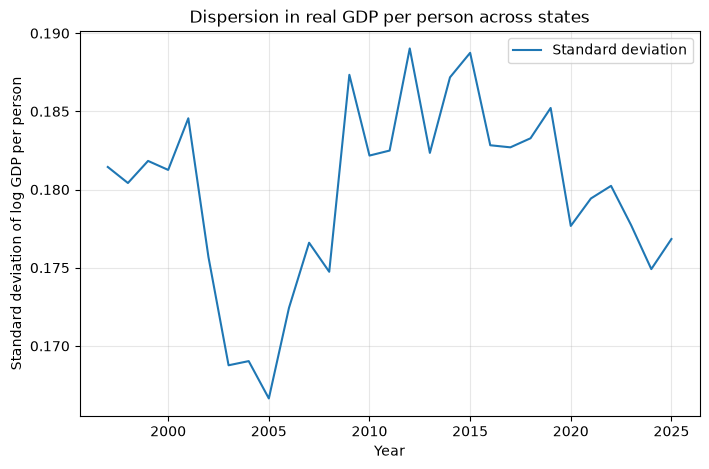

Standard deviation in 1997: 0.1814
Standard deviation in 2025: 0.1768
Highest standard deviation: 0.1890 in 2012
Lowest standard deviation: 0.1666 in 2005


In [ ]:
# 1.2.1 Standard deviation of log real GDP per person

# Take the logarithm of GDP per person
log_y = np.log(y)

# Standard deviation across all states for each year
std_log_y = log_y.std(axis=1, ddof=0)

# Plot the standard deviation over time
plt.figure(figsize=(8, 5))

plt.plot(std_log_y.index, std_log_y, label='Standard deviation')

plt.xlabel('Year')
plt.ylabel('Standard deviation of log GDP per person')
plt.title('Dispersion in real GDP per person across states')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# 1.2.2 Report dispersion in the first and last year and its highest and lowest values

# First and last year
tfirst = std_log_y.index.min()
tlast = std_log_y.index.max()

# Year with highest and lowest standard deviation
year_highest = std_log_y.idxmax()
year_lowest = std_log_y.idxmin()

# Report results
print(f"Standard deviation in {tfirst}: {std_log_y.loc[tfirst]:.4f}")
print(f"Standard deviation in {tlast}: {std_log_y.loc[tlast]:.4f}")
print(f"Highest standard deviation: {std_log_y.loc[year_highest]:.4f} in {year_highest}")
print(f"Lowest standard deviation: {std_log_y.loc[year_lowest]:.4f} in {year_lowest}")

### 1.3 Question 3


#### 1.3.2 Fitted line and correlation

Using `np.polyfit`, we obtain $a = 0.118089$ and $b = -0.009802$.

The fitted line is therefore

$$
g_i = 0.118089 - 0.009802 \log(y_{i,tfirst})
$$

The correlation between $g_i$ and $\log(y_{i,tfirst})$ is $-0.3886$.

#### 1.3.3 States with the highest and lowest growth rates

The five states with the highest average annual growth rates are North Dakota, California, Washington, Massachusetts and South Dakota.

The five states with the lowest average annual growth rates are Nevada, Alaska, Delaware, Louisiana and Connecticut.


#### 1.3.4 Speed of convergence and half-life

The annual speed of convergence is $\lambda = 0.0115$, and the half-life is 60.49 years.

This means that about 1.15% of the initial gap disappears each year, and it takes about 60.5 years for half of the initial gap to disappear.


#### 1.3.5 Description of the convergence figure

The figure shows a negative relationship between initial real GDP per person and average annual growth. States with lower initial GDP per person tend to have higher growth rates.

However, the points are quite spread out around the fitted line, so the relationship is not very strong. This is consistent with the correlation of -0.3886.

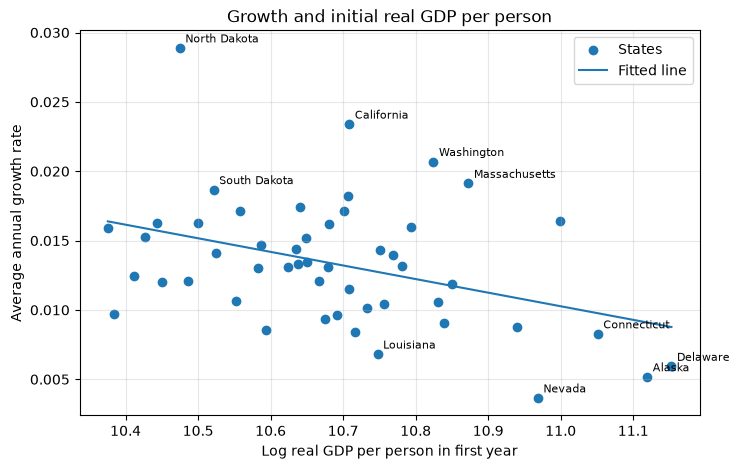

a = 0.118089
b = -0.009802
Correlation = -0.3886
Highest-growth states: North Dakota, California, Washington, Massachusetts, South Dakota
Lowest-growth states: Nevada, Alaska, Delaware, Louisiana, Connecticut
Lambda: 0.0115
Half-life: 60.49 years


In [ ]:
# 1.3.1 Scatter plot of growth against initial real GDP per person

# First and last year
tfirst = y.index.min()
tlast = y.index.max()
T = tlast - tfirst

# Log GDP per person in the first and last year
log_y_first = np.log(y.loc[tfirst])
log_y_last = np.log(y.loc[tlast])

# Average annual growth rate for each state
g = (log_y_last - log_y_first) / T

# Fit g = a + b*log(y_first)
b, a = np.polyfit(log_y_first, g, 1)

# Correlation between growth and initial GDP per person
correlation = np.corrcoef(log_y_first, g)[0, 1]

# Values for the fitted line
x_line = np.linspace(log_y_first.min(), log_y_first.max(), 100)
g_line = a + b * x_line

# Find the five states with highest and lowest growth
highest_growth = g.nlargest(5).index
lowest_growth = g.nsmallest(5).index

# Full state names for figure annotations
state_names = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Scatter plot with fitted line and selected state names
plt.figure(figsize=(8, 5))
plt.scatter(log_y_first, g, label='States')
plt.plot(x_line, g_line, label='Fitted line')

for state in highest_growth.union(lowest_growth):
    plt.annotate(
        state_names[state],
        (log_y_first[state], g[state]),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Log real GDP per person in first year')
plt.ylabel('Average annual growth rate')
plt.title('Growth and initial real GDP per person')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Report results
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Correlation = {correlation:.4f}")
print("Highest-growth states:", ', '.join(state_names[state] for state in highest_growth))
print("Lowest-growth states:", ', '.join(state_names[state] for state in lowest_growth))

# Compute the speed of convergence and half-life
lambda_ = -np.log(1 + b * T) / T
h = np.log(2) / lambda_

print(f"Lambda: {lambda_:.4f}")
print(f"Half-life: {h:.2f} years")

### 1.4 Question 4

#### 1.4.1 Number of states by region

There are 16 states in the South, 13 in the West, 12 in the Midwest and 9 in the Northeast.

#### 1.4.3 Changes in relative GDP per person by region

From 1997 to 2025, the Midwest increased from 0.9683 to 1.0055, the Northeast increased from 1.0873 to 1.0952, the South decreased from 0.9513 to 0.9054, and the West increased from 1.0287 to 1.0454.

The South experienced the largest change, falling by 0.0459 relative to the overall state average.

South        16
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64


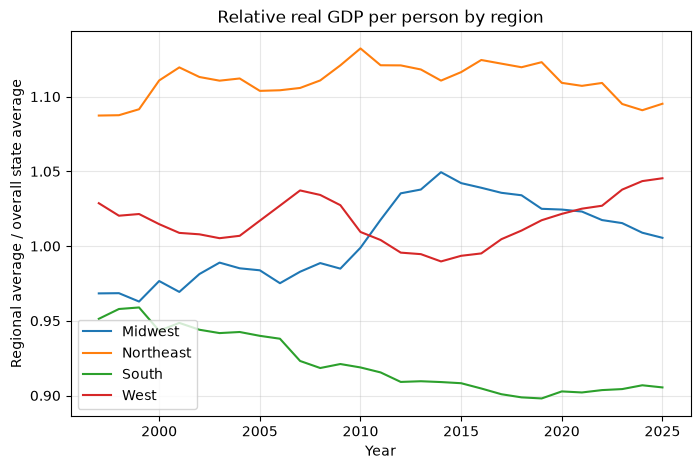

,First year,Last year,Change
Midwest,0.9683,1.0055,0.0372
Northeast,1.0873,1.0952,0.0079
South,0.9513,0.9054,-0.0459
West,1.0287,1.0454,0.0167


Largest movement: South
Change: -0.0459


In [ ]:
# 1.4.1 Compute average relative GDP per person by region

# GDP per person relative to the average across all states
y_relative = y.div(y.mean(axis=1), axis=0)

# Group states by region and take the average within each region
region_relative = y_relative.T.groupby(REGION).mean().T

# Number of states in each region
region_counts = pd.Series(REGION).value_counts()

# Reporting number of states
print(region_counts)


# 1.4.2 Plot the four regional series over time

plt.figure(figsize=(8, 5))

# Plot one line for each region
for region in region_relative.columns:
    plt.plot(
        region_relative.index,
        region_relative[region],
        label=region
    )

plt.xlabel('Year')
plt.ylabel('Regional average / overall state average')
plt.title('Relative real GDP per person by region')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# 1.4.3 Report regional values in the first and last year

tfirst = region_relative.index.min()
tlast = region_relative.index.max()

first_values = region_relative.loc[tfirst]
last_values = region_relative.loc[tlast]
change = last_values - first_values

region_table = pd.DataFrame({
    'First year': first_values,
    'Last year': last_values,
    'Change': change
})

display(region_table.round(4))

# Region with the largest absolute change
largest_move = change.abs().idxmax()

print(f"Largest movement: {largest_move}")
print(f"Change: {change[largest_move]:.4f}")

# 2 The Solow model with a time-varying savings rate

### 2.1 Question 1

#### 2.1.1 Steady state
Using `SolowModelClass` and $s=\bar{s}=0.25$, the analytical steady-state values are:

- $k^*=0.760726$
- $y^*=0.912871$
- $c^*=0.684653$

The root finder gives $k^*=0.760726$, which confirms the analytical solution.

#### 2.1.2 Baseline simulation

The model is simulated for $T=100$ periods with $s_t=\bar{s}=0.25$ and $k_0=0.10$:

- $c_0=0.348119$
- $c_{T-1}=0.684653$
- $k_{T-1}=0.760726$

Capital, output and consumption converge toward their steady-state values.

#### 2.1.3 Simulator tests

Both tests pass:

- An economy starting at $k^*$ remains at $k^*$.
- With $s_t=0$, capital follows $k_t=(1-\delta)^t k_0$.

The simulator is implemented in `SolowModel.py`, while this notebook contains the analysis and figures.


k* = 0.760726
y* = 0.912871
c* = 0.684653
k* (root finder) = 0.760726


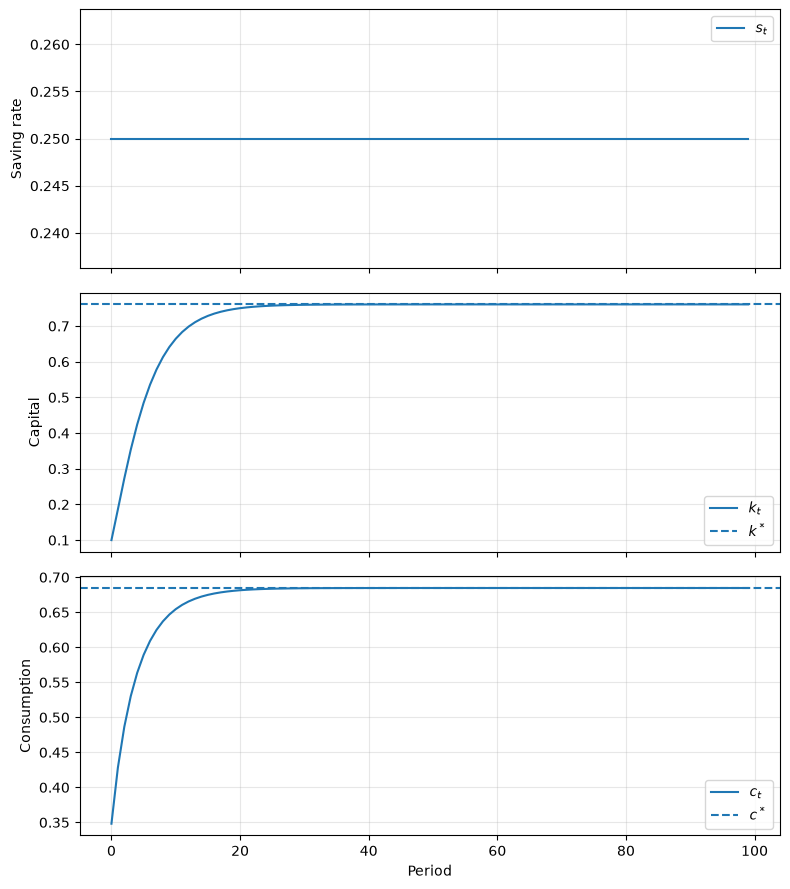

c0 = 0.348119
c(T-1) = 0.684653
k(T-1) = 0.760726
all tests passed


In [ ]:
# 2.1 Model setup and analytical steady state
model = SolowModelClass()
par = model.par
k_star, y_star, c_star = model.steady_state()
k_root = model.solve_steady_state()

print(f'k* = {k_star:.6f}')
print(f'y* = {y_star:.6f}')
print(f'c* = {c_star:.6f}')
print(f'k* (root finder) = {k_root:.6f}')
assert np.isclose(k_star, k_root)

# 2.1.2 Baseline simulation
baseline = model.simulate(par.s_bar)

fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax[0].plot(baseline.s, label=r'$s_t$')
ax[0].set_ylabel('Saving rate')
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].plot(baseline.k, label=r'$k_t$')
ax[1].axhline(k_star, linestyle='--', label=r'$k^*$')
ax[1].set_ylabel('Capital')
ax[1].legend()
ax[1].grid(alpha=0.3)
ax[2].plot(baseline.c, label=r'$c_t$')
ax[2].axhline(c_star, linestyle='--', label=r'$c^*$')
ax[2].set_ylabel('Consumption')
ax[2].set_xlabel('Period')
ax[2].legend()
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'c0 = {baseline.c[0]:.6f}')
print(f'c(T-1) = {baseline.c[-1]:.6f}')
print(f'k(T-1) = {baseline.k[-1]:.6f}')

# 2.1.3 Tests with known answers
def test_simulator():
    steady = SolowModelClass()
    steady_sim = steady.simulate(steady.par.s_bar, k0=k_star)
    assert np.allclose(steady_sim.k, k_star)

    decay = SolowModelClass()
    decay_sim = decay.simulate(0.0)
    expected = decay.par.k0 * (1 - decay.par.delta) ** np.arange(decay.par.T)
    assert np.allclose(decay_sim.k, expected)
    print('all tests passed')

test_simulator()

### 2.2 Question 2

#### 2.2.1-2 Time-varying savings rule and simulations

The model class implements

$$s_t=\bar{s}+(s_0-\bar{s})\phi^t.$$

A higher $s_0$ changes saving mainly in the first periods. Higher initial saving lowers consumption initially, but raises capital and therefore later output and consumption. The parameter $\phi$ controls how persistent the initial deviation is: a higher $\phi$ makes the saving rate return more slowly toward $\bar{s}$.

#### 2.2.3 Final capital

| Case | $k_{T-1}$ |
|---|---:|
| Baseline | 0.760726 |
| $s_0=0.30,\ \phi=0.50$ | 0.760726 |
| $s_0=0.40,\ \phi=0.80$ | 0.760726 |
| $s_0=0.10,\ \phi=0.50$ | 0.760726 |
| $s_0=0.60,\ \phi=0.60$ | 0.760726 |

The values are equal to six decimal places because all rules converge toward the same long-run saving rate $\bar{s}$. They are not exactly equal at period $T-1$, since the temporary saving paths affect capital accumulation for many periods.

#### 2.2.4 Interpretation

The figure shows the short-run trade-off clearly. The rule with $s_0=0.60$ has the lowest initial consumption and the highest early capital accumulation. The rule with $s_0=0.10$ has higher initial consumption but lower capital at first. A higher $\phi$ prolongs these effects. As the saving rates converge to $\bar{s}$, all paths converge toward the same steady state.

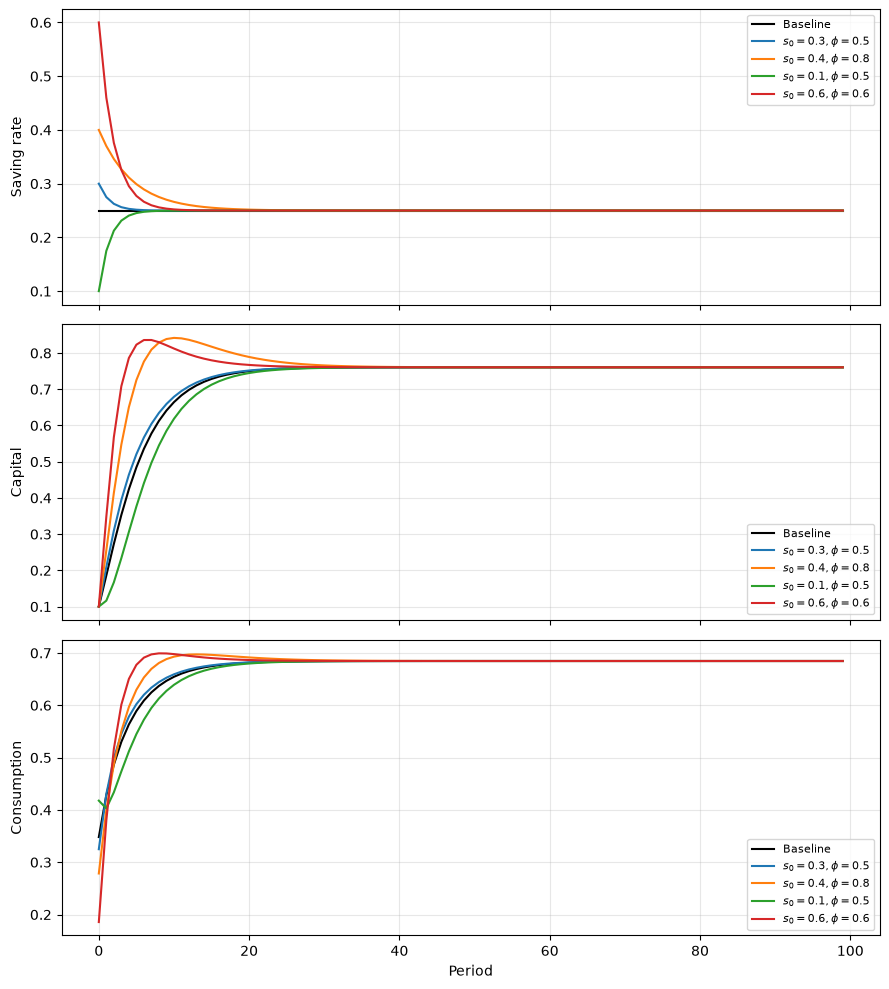

Baseline: k(T-1) = 0.760726
s0=0.3, phi=0.5: k(T-1) = 0.760726
s0=0.4, phi=0.8: k(T-1) = 0.760726
s0=0.1, phi=0.5: k(T-1) = 0.760726
s0=0.6, phi=0.6: k(T-1) = 0.760726


In [ ]:
# 2.2 Time-varying savings rule and simulations
cases = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]
models = {}

for s0, phi in cases:
    case_model = SolowModelClass()
    case_model.simulate(case_model.s_path(s0, phi))
    models[(s0, phi)] = case_model

fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
series = [(None, 'Baseline', 'black')]
for (s0, phi), case_model in models.items():
    series.append(((s0, phi), f'$s_0={s0},\\phi={phi}$', None))

for key, label, color in series:
    sim = baseline if key is None else models[key].sim
    line_color = color if color else None
    ax[0].plot(sim.s, label=label, color=line_color)
    ax[1].plot(sim.k, label=label, color=line_color)
    ax[2].plot(sim.c, label=label, color=line_color)

ax[0].set_ylabel('Saving rate')
ax[1].set_ylabel('Capital')
ax[2].set_ylabel('Consumption')
ax[2].set_xlabel('Period')
for axis in ax:
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Baseline: k(T-1) = {baseline.k[-1]:.6f}')
for (s0, phi), case_model in models.items():
    print(f's0={s0}, phi={phi}: k(T-1) = {case_model.sim.k[-1]:.6f}')

### 2.3 Question 3

#### 2.3.1-2 Welfare results

| Case | $W$ | $W-W_{\mathrm{baseline}}$ |
|---|---:|---:|
| Baseline | -3.994388 | 0.000000 |
| $s_0=0.30,\ \phi=0.50$ | -3.985706 | 0.008682 |
| $s_0=0.40,\ \phi=0.80$ | -4.091413 | -0.097025 |
| $s_0=0.10,\ \phi=0.50$ | -4.146018 | -0.151630 |
| $s_0=0.60,\ \phi=0.60$ | -4.340653 | -0.346265 |

#### 2.3.3 Comparison

Only $(s_0,\phi)=(0.30,0.50)$ gives higher welfare than the baseline. This rule increases saving moderately in the first period and returns quickly toward $\bar{s}$. The figure alone does not identify the best rule, because welfare is a discounted sum of consumption over the whole path.

In [ ]:
# 2.3 Welfare for the baseline and the four time-varying rules
W_baseline = model.welfare(baseline.c)
rows = [{'Case': 'Baseline', 'W': W_baseline, 'Delta W': 0.0}]

for (s0, phi), case_model in models.items():
    W = case_model.welfare(case_model.sim.c)
    rows.append({'Case': f's0={s0}, phi={phi}', 'W': W, 'Delta W': W - W_baseline})

welfare_df = pd.DataFrame(rows)
print(welfare_df.round(6).to_string(index=False))
print('\nRules with welfare above baseline:')
print(welfare_df[(welfare_df['Delta W'] > 0) & (welfare_df['Case'] != 'Baseline')].to_string(index=False))

           Case         W   Delta W
       Baseline -3.994388  0.000000
s0=0.3, phi=0.5 -3.985706  0.008682
s0=0.4, phi=0.8 -4.091413 -0.097025
s0=0.1, phi=0.5 -4.146018 -0.151630
s0=0.6, phi=0.6 -4.340653 -0.346265

Rules with welfare above baseline:
           Case         W  Delta W
s0=0.3, phi=0.5 -3.985706 0.008682


### 2.4 Question 4

#### 2.4.1 Grid search

The welfare grid uses $s_0\in[0,0.60]$ and $\phi\in[0,0.95]$. The best grid point is:

- $s_0=0.310$
- $\phi=0.230$
- $W=-3.984306$

#### 2.4.2 Numerical optimization

Starting from the best grid point, the optimizer finds:

- $s_0=0.311319$
- $\phi=0.229976$
- $W=-3.984301$

The optimizer improves welfare by only $0.000005$ relative to the grid point, so the grid already locates the optimum very closely.

#### 2.4.3 Best rule compared with the baseline

For the optimized rule, $c_0=0.319658$, and consumption is above the baseline for the first time in period 1. The optimized rule saves more than the baseline initially, which lowers current consumption but raises capital and consumption shortly afterward.

Best grid point: s0=0.310, phi=0.230, W=-3.984306


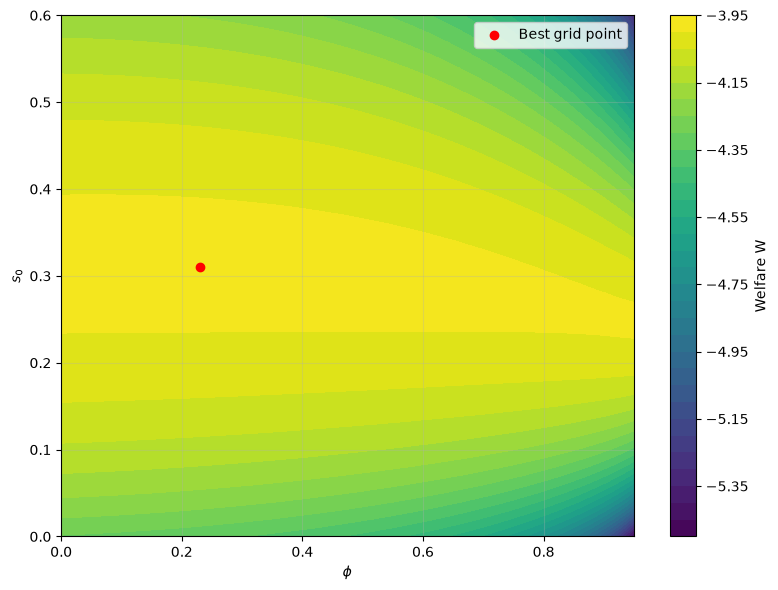

Optimized solution: s0=0.311319, phi=0.229976, W=-3.984301
Difference from grid welfare: 0.000005


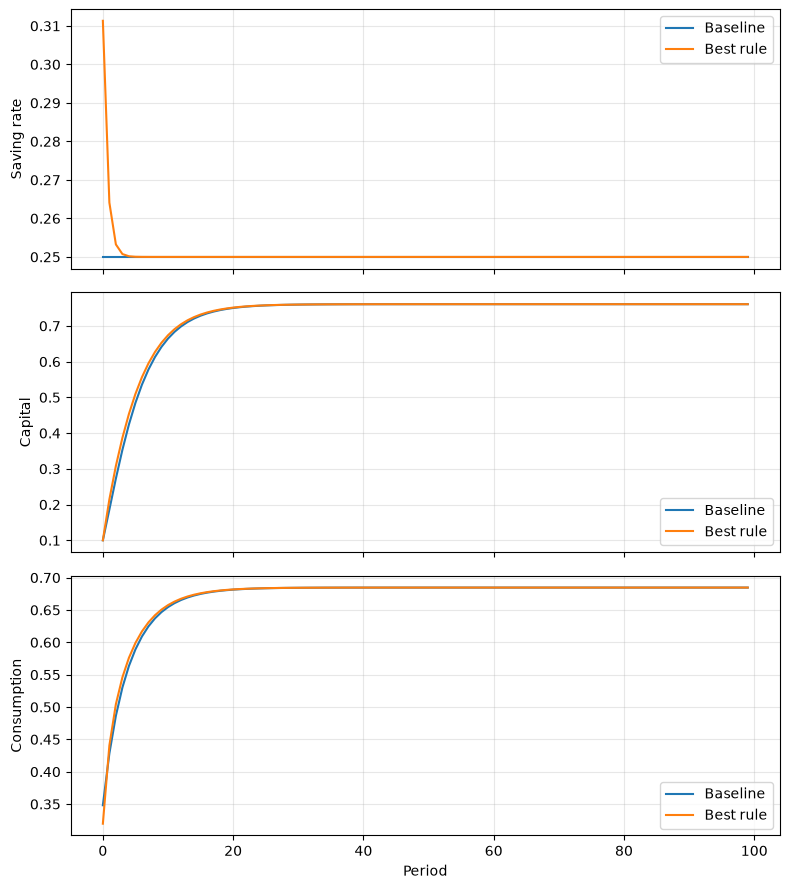

c0 = 0.319658
First period with c above baseline: 1


In [ ]:
# 2.4 Grid search over s0 and phi
s0_grid = np.linspace(0, 0.60, 61)
phi_grid = np.linspace(0, 0.95, 96)
W_grid = np.empty((len(s0_grid), len(phi_grid)))

grid_model = SolowModelClass()
for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i, j] = grid_model.evaluate(s0, phi)

best_idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
best_s0 = s0_grid[best_idx[0]]
best_phi = phi_grid[best_idx[1]]
best_W = W_grid[best_idx]
print(f'Best grid point: s0={best_s0:.3f}, phi={best_phi:.3f}, W={best_W:.6f}')

plt.figure(figsize=(8, 6))
plt.contourf(phi_grid, s0_grid, W_grid, levels=30)
plt.colorbar(label='Welfare W')
plt.scatter(best_phi, best_s0, color='red', label='Best grid point')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$s_0$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2.4.2 Numerical optimization from the best grid point
def objective(x):
    return -grid_model.evaluate(x[0], x[1])

opt = minimize(objective, x0=[best_s0, best_phi], method='SLSQP',
               bounds=[(0, 0.60), (0, 0.95)])
assert opt.success, opt.message
opt_s0, opt_phi = opt.x
opt_W = -opt.fun
print(f'Optimized solution: s0={opt_s0:.6f}, phi={opt_phi:.6f}, W={opt_W:.6f}')
print(f'Difference from grid welfare: {opt_W - best_W:.6f}')

# 2.4.3 Plot the optimized rule against the baseline
opt_model = SolowModelClass()
opt_sim = opt_model.simulate(opt_model.s_path(opt_s0, opt_phi))
fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for axis, baseline_values, optimized_values, ylabel in [
    (ax[0], baseline.s, opt_sim.s, 'Saving rate'),
    (ax[1], baseline.k, opt_sim.k, 'Capital'),
    (ax[2], baseline.c, opt_sim.c, 'Consumption')]:
    axis.plot(baseline_values, label='Baseline')
    axis.plot(optimized_values, label='Best rule')
    axis.set_ylabel(ylabel)
    axis.legend()
    axis.grid(alpha=0.3)
ax[2].set_xlabel('Period')
plt.tight_layout()
plt.show()

above = np.where(opt_sim.c > baseline.c)[0]
first_above = above[0] if above.size else None
print(f'c0 = {opt_sim.c[0]:.6f}')
print(f'First period with c above baseline: {first_above}')

### 2.5 Question 5

#### 2.5.1 Three-parameter optimization

When the long-run saving rate is also chosen, the rule is

$$s_t=s_\infty+(s_0-s_\infty)\phi^t.$$

The optimizer finds:

- $s_0=0.313903$
- $\phi=0.670364$
- $s_\infty=0.198959$
- $W=-3.966965$

Welfare improves by $0.017336$ compared with the optimized two-parameter rule in Question 2.4.

#### 2.5.2 Final capital

The simulated value is $k_{T-1}=0.540088$, compared with the original steady state $k^*=0.760726$. The two values should not be the same: the long-run saving rate is now $s_\infty$, so the relevant steady state is

$$k_\infty^*=\left(\frac{s_\infty}{\delta}\right)^{1/(1-\alpha)}=0.540088.$$

Thus, the economy has converged to the steady state associated with the new long-run saving rate.


In [ ]:
# 2.5 Optimize the three-parameter savings rule

def savings_rule_three(s0, phi, s_inf, T):
    t = np.arange(T)
    return s_inf + (s0 - s_inf) * phi**t

three_model = SolowModelClass()
def objective_three(x):
    s0, phi, s_inf = x
    return -three_model.welfare(
        three_model.simulate(savings_rule_three(s0, phi, s_inf, three_model.par.T)).c
    )

opt3 = minimize(objective_three, x0=[opt_s0, opt_phi, par.s_bar], method='SLSQP',
                bounds=[(0, 1), (0, 0.999), (0, 1)])
assert opt3.success, opt3.message
s0_best, phi_best, s_inf_best = opt3.x
W_best3 = -opt3.fun
sim3 = three_model.simulate(savings_rule_three(s0_best, phi_best, s_inf_best, par.T))

print(f's0 = {s0_best:.6f}')
print(f'phi = {phi_best:.6f}')
print(f's_inf = {s_inf_best:.6f}')
print(f'W = {W_best3:.6f}')
print(f'Improvement over Q2.4 = {W_best3 - opt_W:.6f}')
print(f'k(T-1) = {sim3.k[-1]:.6f}')
print(f'Original k* = {k_star:.6f}')
k_inf = (s_inf_best / par.delta)**(1 / (1 - par.alpha))
print(f'New long-run k* = {k_inf:.6f}')

s0 = 0.313903
phi = 0.670364
s_inf = 0.198959
W = -3.966965
Improvement over Q2.4 = 0.017336
k(T-1) = 0.540088
Original k* = 0.760726
New long-run k* = 0.540088


### 2.6 Question 6

#### 2.6.1-2 Alternative savings rule

As an alternative to the exponential rule, I use a hyperbolic rule:

$$s_t=s_\infty+\frac{s_0-s_\infty}{1+\rho t}.$$

The rule converges to the constant long-run level $s_\infty$, so the economy still converges toward a steady state. Numerical optimization gives:

- $s_0=0.315583$
- $\rho=0.494439$
- $s_\infty=0.179510$
- $W=-3.967244$

#### 2.6.3 Welfare comparison

| Rule | $W$ |
|---|---:|
| Baseline | -3.994388 |
| Best Q2.4 | -3.984301 |
| Best Q2.5 | -3.966965 |
| Alternative | -3.967244 |

The alternative rule improves on the baseline and the two-parameter rule, but it does not beat the optimized three-parameter exponential rule from Question 2.5.


In [ ]:
# 2.6 Alternative savings rule

def savings_rule_alternative(s0, rho, s_inf, T):
    t = np.arange(T)
    return s_inf + (s0 - s_inf) / (1 + rho * t)

alternative_model = SolowModelClass()
def objective_alternative(x):
    s0, rho, s_inf = x
    s = savings_rule_alternative(s0, rho, s_inf, alternative_model.par.T)
    return -alternative_model.welfare(alternative_model.simulate(s).c)

opt_alternative = minimize(objective_alternative,
                           x0=[s0_best, 1.0, s_inf_best],
                           method='SLSQP',
                           bounds=[(0, 0.60), (0, 10.0), (0, 0.60)])
assert opt_alternative.success, opt_alternative.message
s0_alternative, rho_alternative, s_inf_alternative = opt_alternative.x
W_alternative = -opt_alternative.fun

print(f's0 = {s0_alternative:.6f}')
print(f'rho = {rho_alternative:.6f}')
print(f's_inf = {s_inf_alternative:.6f}')
print(f'W = {W_alternative:.6f}')

welfare_comparison = pd.DataFrame({
    'Rule': ['Baseline', 'Best Q2.4', 'Best Q2.5', 'Alternative'],
    'W': [W_baseline, opt_W, W_best3, W_alternative]
})
print(welfare_comparison.round(6).to_string(index=False))

s0 = 0.315583
rho = 0.494439
s_inf = 0.179510
W = -3.967244
       Rule         W
   Baseline -3.994388
  Best Q2.4 -3.984301
  Best Q2.5 -3.966965
Alternative -3.967244


# 3 A portfolio with a risky and a safe asset

### 3.1 Question 1

#### 3.1.1 Simulation of returns

Using `np.random.default_rng(2026)`, the shocks $\varepsilon_t$ were drawn in one array with shape $(N,T)=(50{,}000,40)$. The risky gross returns were then calculated as

$$R_t=\exp(\mu+\sigma\varepsilon_t).$$

#### 3.1.2 Moments of the return distribution

The simulated moments are:

| Quantity | Simulated | Theoretical |
|---|---:|---:|
| Mean of $\log(R_t)$ | 0.050023 | $\mu=0.050000$ |
| Standard deviation of $\log(R_t)$ | 0.199965 | $\sigma=0.200000$ |
| Mean of $R_t$ | 1.072527 | $\exp(\mu+\frac12\sigma^2)=1.072508$ |

The simulated values are very close to the theoretical values. The small differences are sampling variation from the finite number of draws.

#### 3.1.3 Figure

The first panel shows the distribution of the risky gross return. The second panel shows the value of $1$ invested in the risky asset for 20 portfolios and in the safe asset. The risky paths vary substantially because of the shocks, while the safe-asset path is deterministic. The logarithmic y-axis makes relative growth easier to compare.


Mean log(R): 0.050023 (theoretical mu = 0.050000)
Std. log(R): 0.199965 (theoretical sigma = 0.200000)
Mean R: 1.072527 (theoretical value = 1.072508)


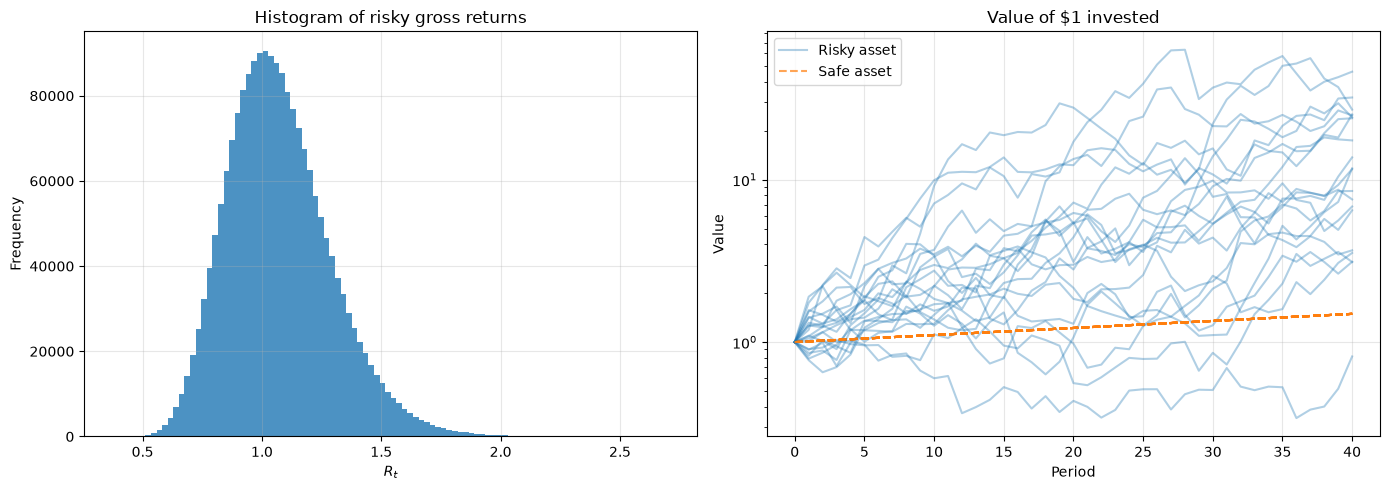

In [ ]:
from PortfolioModel import PortfolioModelClass

# Calibration
par = PortfolioModelClass().par
mu, sigma, r = par.mu, par.sigma, par.r
R_safe = np.exp(r)
T, N = par.T, par.N

# Draw the same risky returns for every experiment
rng = np.random.default_rng(par.seed)
eps = rng.normal(size=(N, T))
R_risky = np.exp(mu + sigma * eps)

# Moments of log returns and gross returns
mean_logR = np.log(R_risky).mean()
std_logR = np.log(R_risky).std()
mean_R = R_risky.mean()
theoretical_mean_R = np.exp(mu + 0.5 * sigma**2)

print(f'Mean log(R): {mean_logR:.6f} (theoretical mu = {mu:.6f})')
print(f'Std. log(R): {std_logR:.6f} (theoretical sigma = {sigma:.6f})')
print(f'Mean R: {mean_R:.6f} (theoretical value = {theoretical_mean_R:.6f})')

# Figure 1: return distribution and value of $1 invested
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(R_risky.ravel(), bins=100, color='tab:blue', alpha=0.8)
ax[0].set(title='Histogram of risky gross returns', xlabel='$R_t$', ylabel='Frequency')
ax[0].grid(alpha=0.3)

time = np.arange(T + 1)
for portfolio in range(20):
    risky_path = np.r_[1, np.cumprod(R_risky[portfolio])]
    safe_path = R_safe ** time
    ax[1].plot(time, risky_path, color='tab:blue', alpha=0.35,
               label='Risky asset' if portfolio == 0 else None)
    ax[1].plot(time, safe_path, '--', color='tab:orange', alpha=0.7,
               label='Safe asset' if portfolio == 0 else None)
ax[1].set(yscale='log', title='Value of $1 invested', xlabel='Period', ylabel='Value')
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Question 2

#### 3.2.1 Portfolio simulator

The simulator loops over the $T=40$ periods and vectorizes over the $N=50{,}000$ portfolios. It stores $W_t$ and $\theta_t$ for $t=0,\ldots,T$. Before each return is realized, the portfolio is rebalanced when $|\theta_t-\theta^*|>\Delta$. The two rules below use exactly the same simulated risky returns.

#### 3.2.2 Extreme trading rules

With transaction costs set to $\tau=0$, the six requested statistics are:

| Rule | Average trades | Average distance | Mean $W_T$ | Median $W_T$ | 10th percentile $W_T$ | Expected utility |
|---|---:|---:|---:|---:|---:|---:|
| $\Delta=0$ | 39.000000 | 0.039395 | 5.043602 | 4.081492 | 1.793667 | -0.067829 |
| $\Delta=1$ | 0.000000 | 0.191138 | 8.975620 | 4.447803 | 1.485479 | -0.076690 |

The $\Delta=0$ rule trades after the initial period whenever the share has moved, so the average number of trades is 39 rather than 40. With $\Delta=1$, no portfolio is traded because the risky share always remains in $[0,1]$.

#### 3.2.4 Figure and description

With continuous rebalancing, the mean risky share stays at the target $\theta^*=0.5$ and the percentile band is relatively narrow. When the portfolio is never traded, the risky share changes after every return shock because the risky and safe assets have different returns. Its dispersion widens over time, and the mean drifts above the target in this simulation.

           Avg trades  Avg distance   Mean WT  Median WT    P10 WT  \
Delta = 0        39.0      0.039395  5.043602   4.081492  1.793667   
Delta = 1         0.0      0.191138  8.975620   4.447803  1.485479   

           Expected utility  
Delta = 0         -0.067829  
Delta = 1         -0.076690  


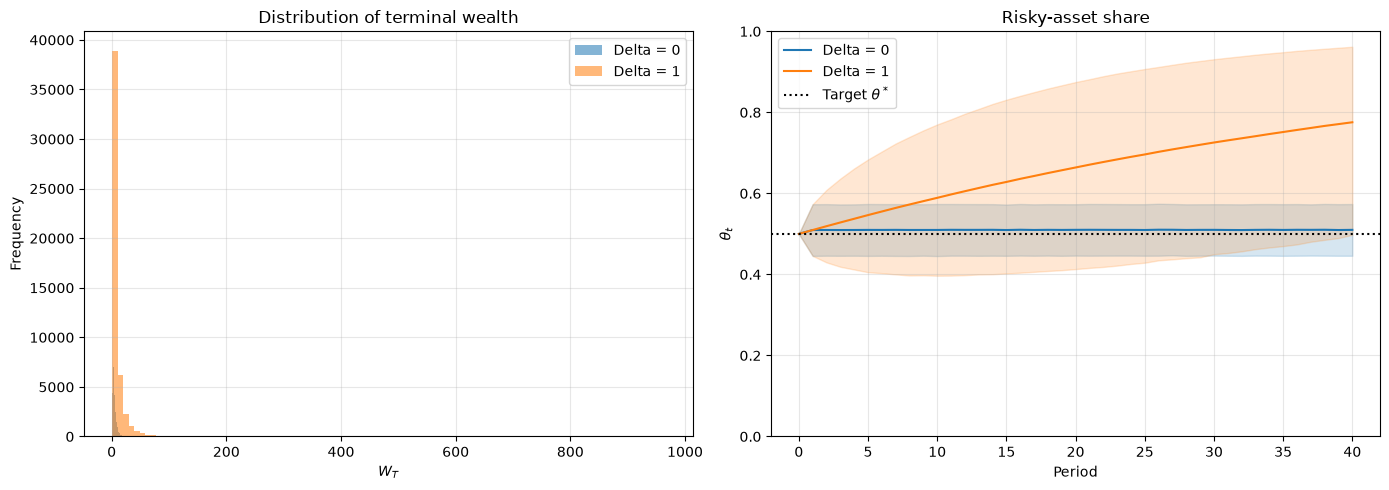

In [ ]:
# 3.2 Simulate the two extreme rules using the same returns
trade_model = PortfolioModelClass(Delta=0, tau=0)
never_model = PortfolioModelClass(Delta=1, tau=0)

trade_model.simulate(R_risky)
never_model.simulate(R_risky)

stats_trade = trade_model.summary()
stats_never = never_model.summary()
comparison = pd.DataFrame([stats_trade, stats_never], index=['Delta = 0', 'Delta = 1'])
print(comparison.round(6))

# Figure 2: terminal wealth and the evolution of risky shares
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(trade_model.sim.W[:, -1], bins=100, alpha=0.55, label='Delta = 0')
ax[0].hist(never_model.sim.W[:, -1], bins=100, alpha=0.55, label='Delta = 1')
ax[0].set(title='Distribution of terminal wealth', xlabel='$W_T$', ylabel='Frequency')
ax[0].legend()
ax[0].grid(alpha=0.3)

for model, label, color in [(trade_model, 'Delta = 0', 'tab:blue'),
                             (never_model, 'Delta = 1', 'tab:orange')]:
    theta = model.sim.theta
    mean_theta = theta.mean(axis=0)
    p10, p90 = np.percentile(theta, [10, 90], axis=0)
    ax[1].plot(time, mean_theta, color=color, label=label)
    ax[1].fill_between(time, p10, p90, color=color, alpha=0.18)
ax[1].axhline(trade_model.par.theta_star, color='black', linestyle=':', label=r'Target $\theta^*$')
ax[1].set(title='Risky-asset share', xlabel='Period', ylabel=r'$\theta_t$', ylim=(0, 1))
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Question 3

#### 3.3.1 Results for different no-trade bands

The six requested statistics are reported below. Average distance is measured before trading and averaged over all portfolios and periods.

| $\Delta$ | Average trades | Average distance | Mean $W_T$ | Median $W_T$ | 10th percentile $W_T$ | Expected utility |
|---:|---:|---:|---:|---:|---:|---:|
| 0.000 | 39.000000 | 0.039395 | 4.962427 | 4.018396 | 1.768274 | -0.069934 |
| 0.025 | 24.523460 | 0.039974 | 4.974622 | 4.018379 | 1.769181 | -0.069745 |
| 0.050 | 14.333420 | 0.042948 | 5.015482 | 4.035755 | 1.767369 | -0.069505 |
| 0.075 | 8.790480 | 0.047986 | 5.073901 | 4.047645 | 1.765500 | -0.069347 |
| 0.100 | 5.860280 | 0.054052 | 5.145886 | 4.060641 | 1.759388 | -0.069460 |
| 0.150 | 3.151900 | 0.068029 | 5.328542 | 4.104170 | 1.735272 | -0.069950 |
| 0.200 | 1.950260 | 0.083468 | 5.559645 | 4.186286 | 1.679246 | -0.070944 |
| 0.300 | 0.905480 | 0.117972 | 6.195680 | 4.341368 | 1.536125 | -0.073406 |
| 1.000 | 0.000000 | 0.191138 | 8.975620 | 4.447803 | 1.485479 | -0.076690 |

#### 3.3.2 Figure

The first panel shows the trade-off between trading activity and distance from the target. The second panel shows expected utility. The two y-axes in the first panel are explicitly labelled because the two measures have different units and scales; grids are included to make both changes easier to read.

#### 3.3.3 Optimal no-trade band

The highest expected utility is obtained at

$$\Delta^*=0.075,$$

where

$$E[u(W_T)]=-0.069347.$$

The improvement relative to $\Delta=0$ is $0.000588$, and the improvement relative to $\Delta=1$ is $0.007343$.

#### 3.3.4 Description

As $\Delta$ increases, the number of trades falls sharply, while the average distance from the target rises. Expected utility first improves because transaction costs are avoided, but then declines because the portfolio is allowed to drift too far from the target and becomes riskier. The best rule is therefore an intermediate band, $\Delta=0.075$.

From $\Delta=0$ to the best rule, the average number of trades falls substantially from 39.00 to 8.79, while the average distance increases from 0.0394 to 0.0480. The terminal wealth statistics change much less: mean wealth increases from 4.9624 to 5.0739, median wealth from 4.0184 to 4.0476, while the 10th percentile remains almost unchanged at around 1.77.

Mean terminal wealth is highest for $\Delta=1$, not for the utility-maximizing rule. Thus, ranking by mean wealth would select a different rule: mean wealth rewards the higher average risky exposure, whereas CRRA expected utility also penalizes the greater downside risk.


 Delta  Avg trades  Avg distance  Mean WT  Median WT   P10 WT  Expected utility
 0.000    39.00000      0.039395 4.962427   4.018396 1.768274         -0.069934
 0.025    24.52346      0.039974 4.974622   4.018379 1.769181         -0.069745
 0.050    14.33342      0.042948 5.015482   4.035755 1.767369         -0.069505
 0.075     8.79048      0.047986 5.073901   4.047645 1.765500         -0.069347
 0.100     5.86028      0.054052 5.145886   4.060641 1.759388         -0.069460
 0.150     3.15190      0.068029 5.328542   4.104170 1.735272         -0.069950
 0.200     1.95026      0.083468 5.559645   4.186286 1.679246         -0.070944
 0.300     0.90548      0.117972 6.195680   4.341368 1.536125         -0.073406
 1.000     0.00000      0.191138 8.975620   4.447803 1.485479         -0.076690


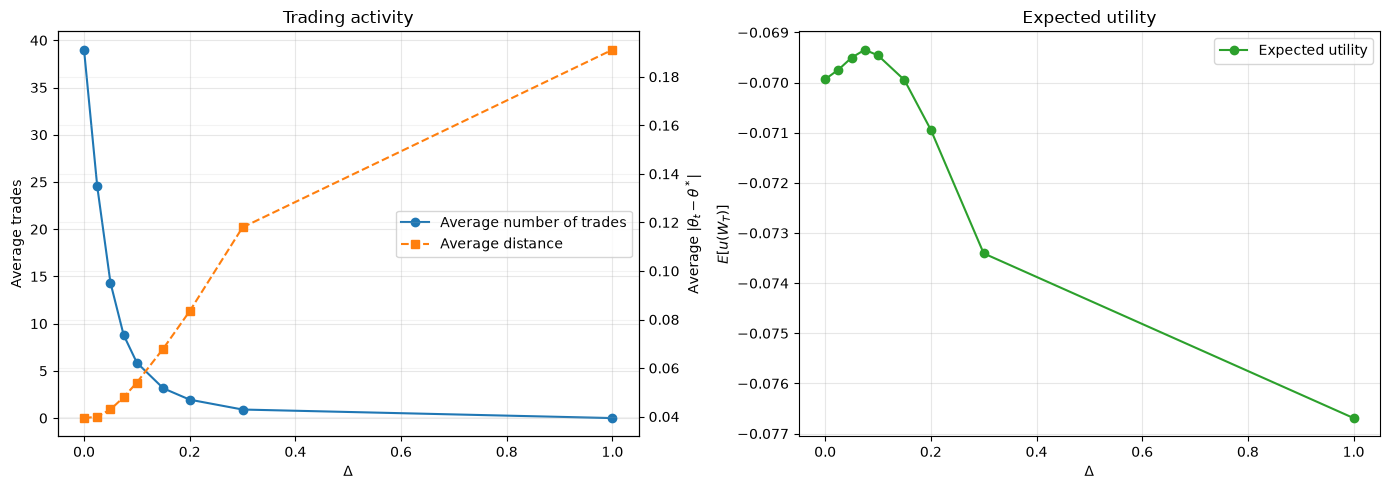

Best Delta: 0.075
Expected utility at best Delta: -0.069347
Improvement relative to Delta=0: 0.000588
Improvement relative to Delta=1: 0.007343
Mean WT is highest at Delta = 1.000.


In [ ]:
# 3.3 Simulate all requested no-trade bands with transaction costs
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1.0]
results = []
models = {}

for Delta in Deltas:
    model = PortfolioModelClass(Delta=Delta, tau=0.01)
    model.simulate(R_risky)
    models[Delta] = model
    row = model.summary()
    row['Delta'] = Delta
    results.append(row)

results_df = pd.DataFrame(results)[
    ['Delta', 'Avg trades', 'Avg distance', 'Mean WT', 'Median WT', 'P10 WT', 'Expected utility']
]
print(results_df.round(6).to_string(index=False))

# Figure 3: trading activity and expected utility
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
line_trades = ax[0].plot(results_df['Delta'], results_df['Avg trades'], 'o-',
                         label='Average number of trades')
ax[0].set(xlabel=r'$\Delta$', ylabel='Average trades', title='Trading activity')
ax[0].grid(alpha=0.3)
ax_distance = ax[0].twinx()
line_distance = ax_distance.plot(results_df['Delta'], results_df['Avg distance'], 's--',
                                 color='tab:orange', label='Average distance')
ax_distance.set_ylabel(r'Average $|\theta_t-\theta^*|$')
ax[0].legend(line_trades + line_distance,
             [line.get_label() for line in line_trades + line_distance], loc='center right')
ax_distance.grid(alpha=0.15)

ax[1].plot(results_df['Delta'], results_df['Expected utility'], 'o-', color='tab:green',
           label='Expected utility')
ax[1].set(xlabel=r'$\Delta$', ylabel=r'$E[u(W_T)]$', title='Expected utility')
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Best rule and comparisons with the two extremes
best_idx = results_df['Expected utility'].idxmax()
best_delta = results_df.loc[best_idx, 'Delta']
best_utility = results_df.loc[best_idx, 'Expected utility']
utility_delta0 = results_df.loc[results_df['Delta'] == 0, 'Expected utility'].iloc[0]
utility_delta1 = results_df.loc[results_df['Delta'] == 1, 'Expected utility'].iloc[0]

print(f'Best Delta: {best_delta:.3f}')
print(f'Expected utility at best Delta: {best_utility:.6f}')
print(f'Improvement relative to Delta=0: {best_utility - utility_delta0:.6f}')
print(f'Improvement relative to Delta=1: {best_utility - utility_delta1:.6f}')
print(f'Mean WT is highest at Delta = {results_df.loc[results_df["Mean WT"].idxmax(), "Delta"]:.3f}.')